In [1]:
import tensorflow as tf

import os
import pathlib
import time
import datetime

from matplotlib import pyplot as plt
from IPython import display

In [2]:
# The facade training set consist of 400 images
BUFFER_SIZE = 400
# The batch size of 1 produced better results for the U-Net in the original pix2pix experiment
BATCH_SIZE = 1
# Each image is 256x256 in size
IMG_WIDTH = 256
IMG_HEIGHT = 256

In [3]:
path_to_zip = tf.keras.utils.get_file(
    fname="facades.tar.gz",
    origin="http://efrosgans.eecs.berkeley.edu/pix2pix/datasets/facades.tar.gz",
    extract=True)

path_to_zip  = pathlib.Path(path_to_zip)

In [4]:
PATH = path_to_zip.parent / "facades"
print(PATH)

/home/yhkim/.keras/datasets/facades


In [5]:
sample_image = tf.io.read_file(str(PATH / 'train/10.jpg'))
sample_image = tf.io.decode_jpeg(sample_image)
print(sample_image.shape)

(256, 512, 3)


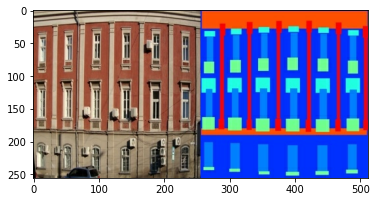

In [6]:
plt.figure()
plt.imshow(sample_image)

In [7]:
def load(image_file):
    # Read and decode an image file to a uint8 tensor
    image = tf.io.read_file(image_file)
    image = tf.image.decode_jpeg(image)

    # Split each image tensor into two tensors
    w = tf.shape(image)[1] // 2
    input_image = image[:, w:, :]
    real_image = image[:, :w, :]

    # Convert both images to float32 tensors
    input_image = tf.cast(input_image, tf.float32)
    real_image = tf.cast(real_image, tf.float32)

    return input_image, real_image

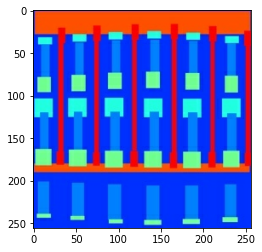

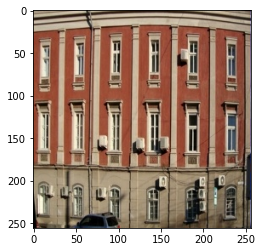

In [8]:
inp, tar = load(str(PATH / 'train/10.jpg'))
# Casting to int for matplotlib to display the images
plt.figure()
plt.imshow(inp / 255.0)
plt.figure()
plt.imshow(tar / 255.0)

In [9]:
def resize(input_image, real_image, height, width):
    input_image = tf.image.resize(input_image, [height, width],
                                  method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)
    real_image = tf.image.resize(real_image, [height, width],
                                 method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)

    return input_image, real_image

In [10]:
def random_crop(input_image, real_image):
    stacked_image = tf.stack([input_image, real_image], axis=0)
    cropped_image = tf.image.random_crop(
      stacked_image, size=[2, IMG_HEIGHT, IMG_WIDTH, 3])

    return cropped_image[0], cropped_image[1]

In [11]:
def normalize(input_image, real_image):
    input_image = (input_image / 127.5) - 1
    real_image = (real_image / 127.5) - 1

    return input_image, real_image

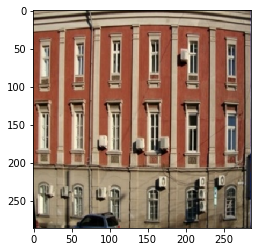

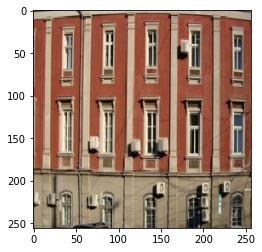

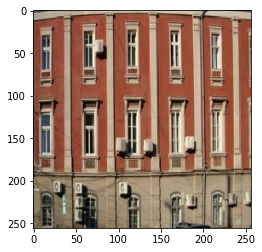

In [12]:
# Resizing to 286x286
input_image, real_image = resize(inp, tar, 286, 286)

plt.figure()
plt.imshow(real_image / 255.0)
# Random cropping back to 256x256
input_image, real_image = random_crop(input_image, real_image)

plt.figure()
plt.imshow(real_image / 255.0)
# Random mirroring
input_image = tf.image.flip_left_right(input_image)
real_image = tf.image.flip_left_right(real_image)
    
plt.figure()
plt.imshow(real_image / 255.0)

In [13]:
@tf.function()
def random_jitter(input_image, real_image):
    # Resizing to 286x286
    input_image, real_image = resize(input_image, real_image, 286, 286)

    # Random cropping back to 256x256
    input_image, real_image = random_crop(input_image, real_image)

    if tf.random.uniform(()) > 0.5:
        # Random mirroring
        input_image = tf.image.flip_left_right(input_image)
        real_image = tf.image.flip_left_right(real_image)

    return input_image, real_image

In [14]:
def load_image_train(image_file):
    input_image, real_image = load(image_file)
    input_image, real_image = random_jitter(input_image, real_image)
    input_image, real_image = normalize(input_image, real_image)

    return input_image, real_image

In [15]:
def load_image_test(image_file):
    input_image, real_image = load(image_file)
    input_image, real_image = resize(input_image, real_image,
                                   IMG_HEIGHT, IMG_WIDTH)
    input_image, real_image = normalize(input_image, real_image)

    return input_image, real_image

In [16]:
train_dataset = tf.data.Dataset.list_files(str(PATH / 'train/*.jpg'))
train_dataset = train_dataset.map(load_image_train) \
                             .shuffle(BUFFER_SIZE) \
                             .batch(BATCH_SIZE)

In [17]:
test_dataset = tf.data.Dataset.list_files(str(PATH / 'test/*.jpg'))
test_dataset = test_dataset.map(load_image_test).batch(BATCH_SIZE)

In [18]:
def downsample(filters, size, apply_batchnorm=True):
    initializer = tf.random_normal_initializer(0., 0.02)

    result = tf.keras.Sequential()
    result.add(tf.keras.layers.Conv2D(filters, size, strides=2, padding='same',
                                     kernel_initializer=initializer, use_bias=False))

    if apply_batchnorm:
        result.add(tf.keras.layers.BatchNormalization())

    result.add(tf.keras.layers.LeakyReLU())

    return result

In [19]:
def upsample(filters, size, apply_dropout=False):
    initializer = tf.random_normal_initializer(0., 0.02)

    result = tf.keras.Sequential()
    result.add(tf.keras.layers.Conv2DTranspose(filters, size, strides=2,
                                            padding='same',
                                            kernel_initializer=initializer,
                                            use_bias=False))

    result.add(tf.keras.layers.BatchNormalization())

    if apply_dropout:
        result.add(tf.keras.layers.Dropout(0.5))

    result.add(tf.keras.layers.ReLU())

    return result

In [20]:
def make_generator_model():
    inputs = tf.keras.layers.Input(shape=[256, 256, 3])

    x1 = downsample(64, 4, apply_batchnorm=False)(inputs)  # (batch_size, 128, 128, 64)
    x2 = downsample(128, 4)(x1)  # (batch_size, 64, 64, 128)
    x3 = downsample(256, 4)(x2)  # (batch_size, 32, 32, 256)
    x4 = downsample(512, 4)(x3)  # (batch_size, 16, 16, 512)
    x5 = downsample(512, 4)(x4)  # (batch_size, 8, 8, 512)
    x6 = downsample(512, 4)(x5)  # (batch_size, 4, 4, 512)
    x7 = downsample(512, 4)(x6)  # (batch_size, 2, 2, 512)
    x8 = downsample(512, 4)(x7)  # (batch_size, 1, 1, 512)

    y = upsample(512, 4, apply_dropout=True)(x8)  # (batch_size, 2, 2, 1024)
    y = tf.keras.layers.Concatenate()([y, x7])
    y = upsample(512, 4, apply_dropout=True)(y)  # (batch_size, 4, 4, 1024)
    y = tf.keras.layers.Concatenate()([y, x6])
    y = upsample(512, 4, apply_dropout=True)(y)  # (batch_size, 8, 8, 1024)
    y = tf.keras.layers.Concatenate()([y, x5])
    y = upsample(512, 4)(y)  # (batch_size, 16, 16, 1024)
    y = tf.keras.layers.Concatenate()([y, x4])
    y = upsample(256, 4)(y)  # (batch_size, 32, 32, 512)
    y = tf.keras.layers.Concatenate()([y, x3])
    y = upsample(128, 4)(y)  # (batch_size, 64, 64, 256
    y = tf.keras.layers.Concatenate()([y, x2])
    y = upsample(64, 4)(y)  # (batch_size, 128, 128, 128)
    y = tf.keras.layers.Concatenate()([y, x1])

    initializer = tf.random_normal_initializer(0., 0.02)
    last = tf.keras.layers.Conv2DTranspose(3, 4,
                                         strides=2,
                                         padding='same',
                                         kernel_initializer=initializer,
                                         activation='tanh')  # (batch_size, 256, 256, 3)
    y = last(y)
    
    return tf.keras.Model(inputs=inputs, outputs=y)

In [21]:
generator = make_generator_model()

In [22]:
!pip3 install pydot
!pip3 install graphviz

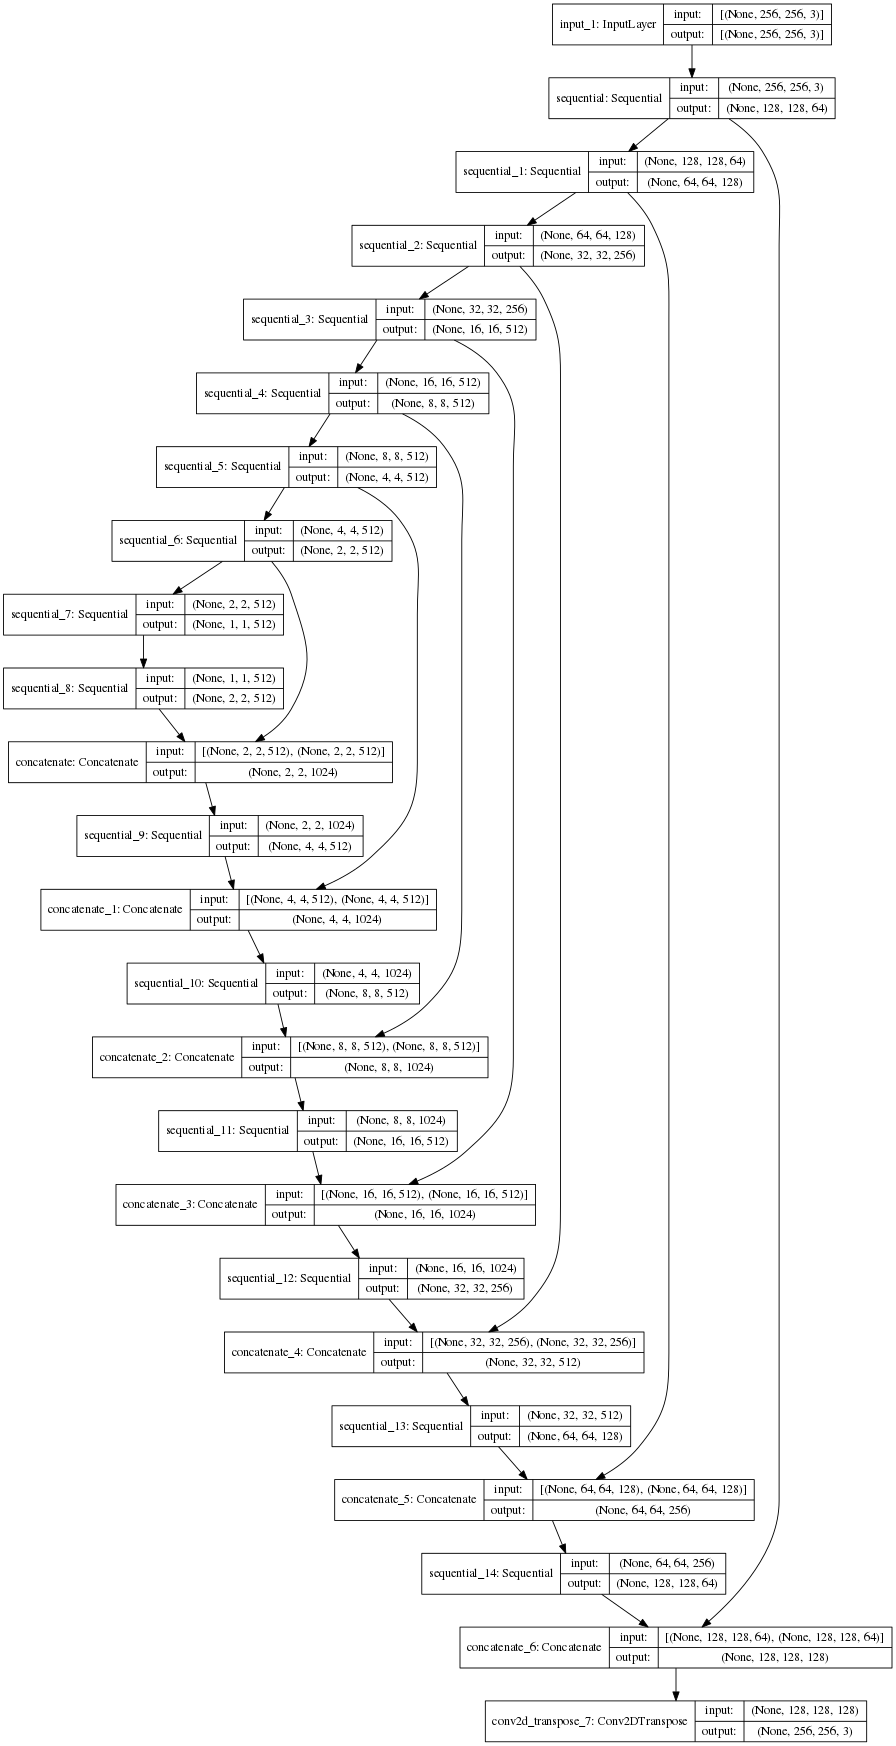

In [23]:
tf.keras.utils.plot_model(generator, show_shapes=True, dpi=64)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


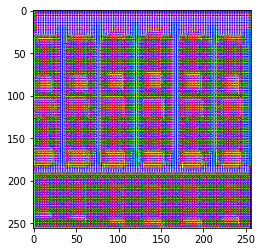

In [24]:
gen_output = generator(inp[tf.newaxis, ...], training=False)
plt.imshow(gen_output[0, ...])

In [26]:
def make_discriminator_model():
    initializer = tf.random_normal_initializer(0., 0.02)

    inp = tf.keras.layers.Input(shape=[256, 256, 3], name='input_image')
    tar = tf.keras.layers.Input(shape=[256, 256, 3], name='target_image')

    x = tf.keras.layers.concatenate([inp, tar])  # (batch_size, 256, 256, channels*2)

    down1 = downsample(64, 4, False)(x)  # (batch_size, 128, 128, 64)
    down2 = downsample(128, 4)(down1)  # (batch_size, 64, 64, 128)
    down3 = downsample(256, 4)(down2)  # (batch_size, 32, 32, 256)

    zero_pad1 = tf.keras.layers.ZeroPadding2D()(down3)  # (batch_size, 34, 34, 256)
    conv = tf.keras.layers.Conv2D(512, 4, strides=1,
                                kernel_initializer=initializer,
                                use_bias=False)(zero_pad1)  # (batch_size, 31, 31, 512)

    batchnorm1 = tf.keras.layers.BatchNormalization()(conv)

    leaky_relu = tf.keras.layers.LeakyReLU()(batchnorm1)

    zero_pad2 = tf.keras.layers.ZeroPadding2D()(leaky_relu)  # (batch_size, 33, 33, 512)

    last = tf.keras.layers.Conv2D(1, 4, strides=1,
                                kernel_initializer=initializer)(zero_pad2)  # (batch_size, 30, 30, 1)

    return tf.keras.Model(inputs=[inp, tar], outputs=last)

In [27]:
discriminator = make_discriminator_model()

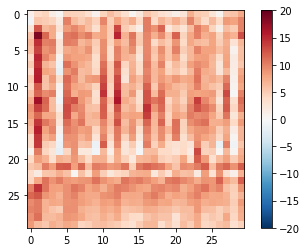

In [31]:
disc_out = discriminator([inp[tf.newaxis, ...], gen_output], training=False)
plt.imshow(disc_out[0, ..., -1], vmin=-20, vmax=20, cmap='RdBu_r')
plt.colorbar()

In [25]:
loss_object = tf.keras.losses.BinaryCrossentropy(from_logits=True)

In [60]:
def generator_loss(disc_generated_output, gen_output, target):
    gan_loss = loss_object(tf.ones_like(disc_generated_output), disc_generated_output)

    # Mean absolute error
    l1_loss = tf.reduce_mean(tf.abs(target - gen_output))

    total_gen_loss = gan_loss + (10. * l1_loss)

    return total_gen_loss, gan_loss, l1_loss

In [61]:
def discriminator_loss(disc_real_output, disc_generated_output):
    real_loss = loss_object(tf.ones_like(disc_real_output), disc_real_output)

    generated_loss = loss_object(tf.zeros_like(disc_generated_output), disc_generated_output)

    total_disc_loss = real_loss + generated_loss

    return total_disc_loss

In [ ]:
def generate_images(model, test_input, tar):
    prediction = model(test_input, training=True)
    plt.figure(figsize=(15, 15))

    display_list = [test_input[0], tar[0], prediction[0]]
    title = ['Input Image', 'Ground Truth', 'Predicted Image']

    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.title(title[i])
        # Getting the pixel values in the [0, 1] range to plot.
        plt.imshow(display_list[i] * 0.5 + 0.5)
        plt.axis('off')
    plt.show()

In [62]:
generator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)

In [65]:
@tf.function
def train_step(input_image, target):
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        gen_output = generator(input_image, training=True)

        disc_real_output = discriminator([input_image, target], training=True)
        disc_generated_output = discriminator([input_image, gen_output], training=True)

        gen_total_loss, gen_gan_loss, gen_l1_loss = generator_loss(disc_generated_output, gen_output, target)
        disc_loss = discriminator_loss(disc_real_output, disc_generated_output)

    generator_gradients = gen_tape.gradient(gen_total_loss,
                                          generator.trainable_variables)
    discriminator_gradients = disc_tape.gradient(disc_loss,
                                               discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(generator_gradients,
                                          generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(discriminator_gradients,
                                              discriminator.trainable_variables))

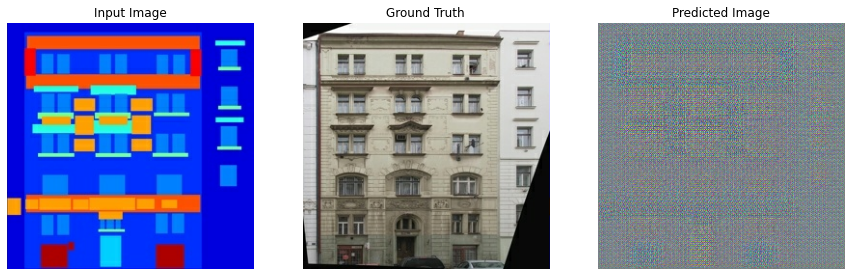

In [70]:
example_input, example_target = tuple(test_dataset.take(1))[0]
generate_images(generator, example_input, example_target)

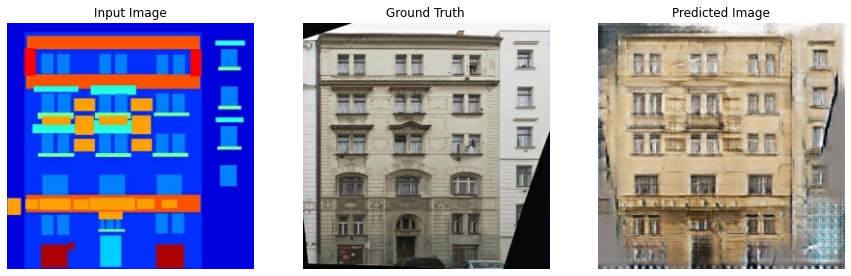

In [71]:
for epoch in range(50):
    start = time.time()

    for input_image, target_image in train_dataset:
        train_step(input_image, target_image)

    display.clear_output(wait=True)
    generate_images(generator, example_input, example_target)

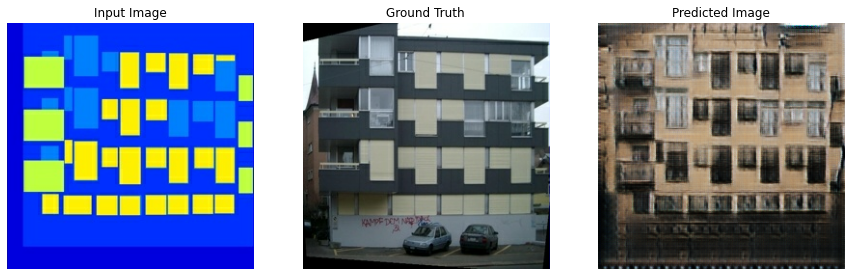

In [72]:
example_input, example_target = tuple(test_dataset.take(1))[0]
generate_images(generator, example_input, example_target)

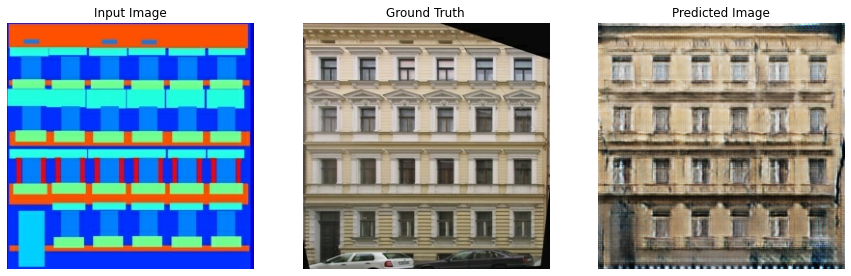

In [73]:
example_input, example_target = tuple(test_dataset.take(1))[0]
generate_images(generator, example_input, example_target)

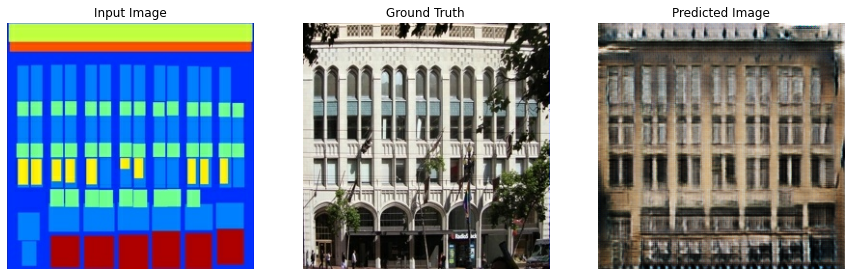

In [74]:
example_input, example_target = tuple(test_dataset.take(1))[0]
generate_images(generator, example_input, example_target)

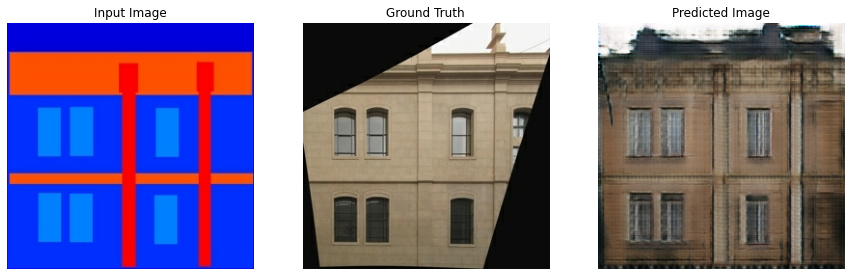

In [75]:
example_input, example_target = tuple(test_dataset.take(1))[0]
generate_images(generator, example_input, example_target)

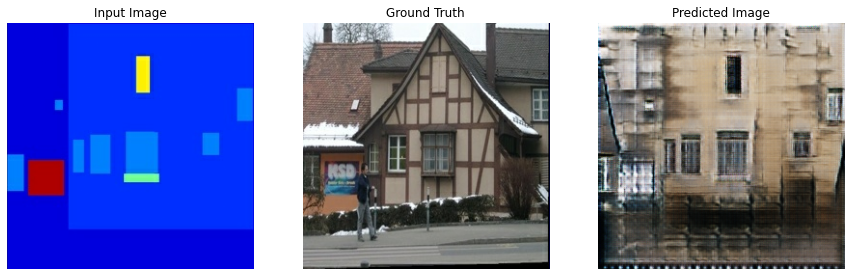

In [76]:
example_input, example_target = tuple(test_dataset.take(1))[0]
generate_images(generator, example_input, example_target)

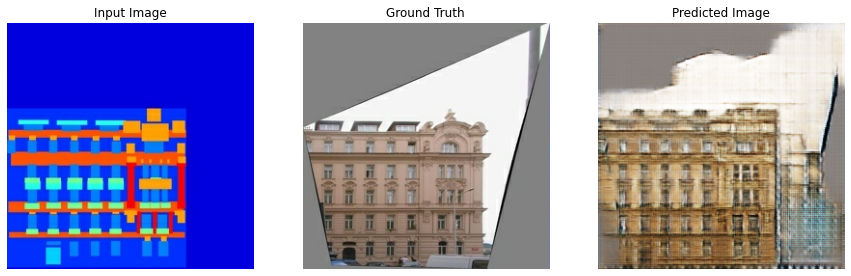

In [77]:
example_input, example_target = tuple(test_dataset.take(1))[0]
generate_images(generator, example_input, example_target)

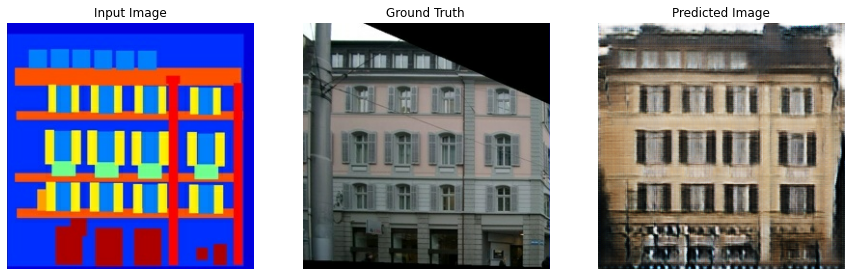

In [78]:
example_input, example_target = tuple(test_dataset.take(1))[0]
generate_images(generator, example_input, example_target)

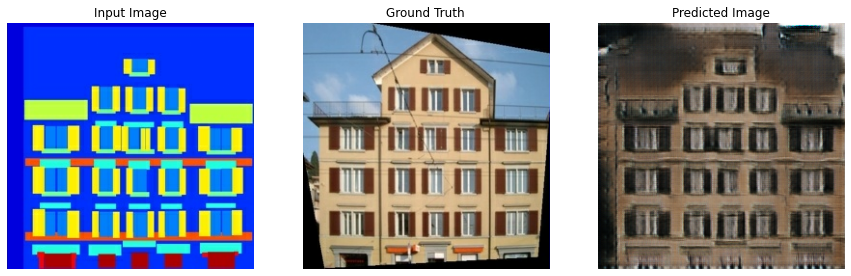

In [79]:
example_input, example_target = tuple(test_dataset.take(1))[0]
generate_images(generator, example_input, example_target)